# 1. Data Collection: SPY (SPDR S&P 500 ETF Trust)

Research pipeline, step 1 of 5:
`Data_Collection` → `Feature_Engineering` → `HMM_Regime_Detection` → `CNN_LSTM_Attention` → `Backtesting`

This notebook pulls raw daily OHLCV data for **SPY** (and a few auxiliary series that are useful downstream:
**^VIX** for volatility regime context and **^TNX** for the 10Y yield as a macro feature), cleans it,
and persists it to disk.




In [511]:
!pip install ta
!pip install hmmlearn

In [512]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import json, os, random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

TICKER = "SPY"
START = "2005-01-01"   # long enough to span multiple bull/bear regimes (incl. 2008, 2020)
END = None             # None -> up to today


### 1.1 Download raw OHLCV for SPY

In [513]:
def download_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker/date range/network.")
    # yfinance sometimes returns a MultiIndex column header even for a single ticker
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index.name = "Date"
    df = df.rename(columns=str.title)
    return df

spy_raw = download_ohlcv(TICKER, START, END)
print(spy_raw.shape)
spy_raw.tail()


(5418, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-07-13,749.169983,749.169983,753.909973,748.000000,752.469971,44013600
2026-07-14,751.830017,751.830017,753.340027,748.659973,750.909973,35143100
2026-07-15,754.809998,754.809998,755.580017,750.200012,754.239990,43844800
2026-07-16,750.719971,750.719971,754.570007,747.880005,752.760010,46409800
2026-07-17,743.289978,743.289978,747.289978,740.799988,742.080017,62569200


### 1.2 Download auxiliary series: VIX (volatility index) and 10Y Treasury yield

In [514]:
vix_raw = download_ohlcv("^VIX", START, END)[["Close"]].rename(columns={"Close": "VIX_Close"})
tnx_raw = download_ohlcv("^TNX", START, END)[["Close"]].rename(columns={"Close": "TNX_Close"})

print("VIX:", vix_raw.shape, " TNX:", tnx_raw.shape)


VIX: (5420, 1)  TNX: (5414, 1)


### 1.3 Merge, clean, and validate

In [515]:
df = spy_raw.join(vix_raw, how="left").join(tnx_raw, how="left")

# Forward-fill small gaps in auxiliary series (different holiday calendars), but never ffill SPY itself
df["VIX_Close"] = df["VIX_Close"].ffill()
df["TNX_Close"] = df["TNX_Close"].ffill()

# Drop any residual rows where core SPY OHLCV is missing
core_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
before = len(df)
df = df.dropna(subset=core_cols)
after = len(df)
print(f"Dropped {before - after} rows with missing core OHLCV")

# Sanity checks
assert (df["High"] >= df["Low"]).all(), "High < Low detected"
assert (df["Volume"] >= 0).all(), "Negative volume detected"
assert df.index.is_monotonic_increasing, "Index not sorted"
assert not df.index.duplicated().any(), "Duplicate dates found"

df.head()


Dropped 0 rows with missing core OHLCV


Price,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close
Date,,,,,,,,
2005-01-03,81.174606,120.300003,121.760002,119.900002,121.559998,55748000,14.08,4.220
2005-01-04,80.182716,118.830002,120.540001,118.440002,120.459999,69167600,13.98,4.283
2005-01-05,79.629379,118.010002,119.250000,118.000000,118.739998,65667300,14.09,4.277
2005-01-06,80.034264,118.610001,119.150002,118.260002,118.440002,47814700,13.58,4.272
2005-01-07,79.919510,118.440002,119.230003,118.129997,118.970001,55847700,13.49,4.285


### 1.4 Quick visual sanity check

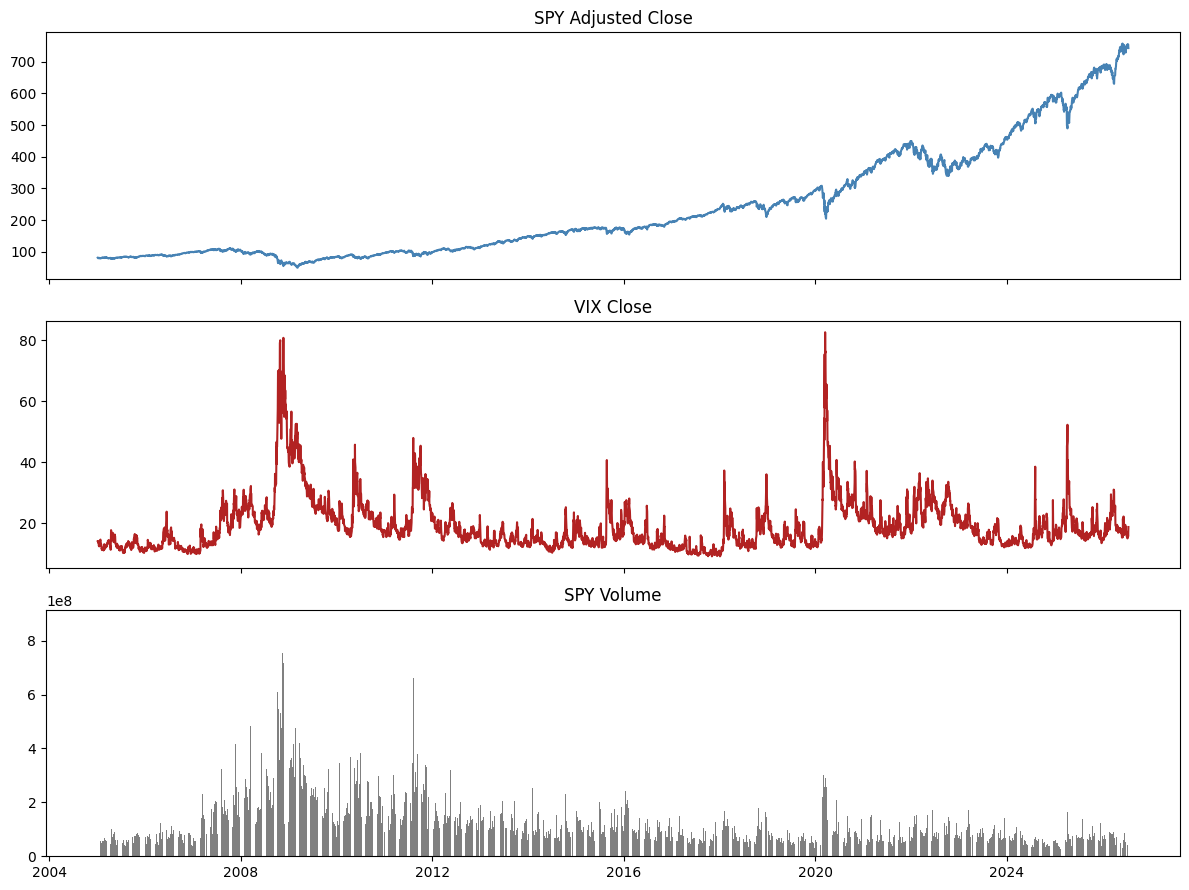

In [516]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df.index, df["Adj Close"], color="steelblue")
axes[0].set_title("SPY Adjusted Close")

axes[1].plot(df.index, df["VIX_Close"], color="firebrick")
axes[1].set_title("VIX Close")

axes[2].bar(df.index, df["Volume"], color="gray", width=1.0)
axes[2].set_title("SPY Volume")

plt.tight_layout()
plt.show()


### 1.5 Persist raw dataset

In [517]:
out_path = os.path.join(DATA_DIR, "spy_raw.csv")
df.to_csv(out_path)
print(f"Saved {len(df)} rows to {out_path}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")


Saved 5418 rows to data/spy_raw.csv
Date range: 2005-01-03 -> 2026-07-17


# 2. Feature Engineering:  SPY

Step 2 of 5. Loads `data/spy_raw.csv`  and builds the feature set consumed by
both the HMM regime model and the CNN-LSTM-Attention model:

- Return-based features (log returns, multi-horizon momentum)
- Volatility features (rolling realized vol, ATR, VIX-based)
- Trend/momentum indicators (SMA/EMA, MACD, RSI, ADX)
- Mean-reversion indicators (Bollinger Bands, z-score of price)
- Volume features
- Calendar features



In [518]:
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_raw.csv"), index_col="Date", parse_dates=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close
Date,,,,,,,,
2026-07-13,749.169983,749.169983,753.909973,748.000000,752.469971,44013600,17.16,4.609
2026-07-14,751.830017,751.830017,753.340027,748.659973,750.909973,35143100,16.50,4.585
2026-07-15,754.809998,754.809998,755.580017,750.200012,754.239990,43844800,15.67,4.545
2026-07-16,750.719971,750.719971,754.570007,747.880005,752.760010,46409800,16.73,4.569
2026-07-17,743.289978,743.289978,747.289978,740.799988,742.080017,62569200,18.77,4.541


### 2.1 Returns

In [519]:
px = df["Adj Close"]

df["log_ret_1d"] = np.log(px / px.shift(1))
for h in [5, 10, 21, 63]:  # ~1wk, 2wk, 1mo, 1qtr trading days
    df[f"ret_{h}d"] = px.pct_change(h)

df[["log_ret_1d", "ret_5d", "ret_10d", "ret_21d", "ret_63d"]].tail()


,log_ret_1d,ret_5d,ret_10d,ret_21d,ret_63d
Date,,,,,
2026-07-13,-0.007686,-0.002809,0.027682,0.035386,0.105437
2026-07-14,0.003544,0.005510,0.014615,0.021697,0.098625
2026-07-15,0.003956,0.012624,0.010766,0.020229,0.089702
2026-07-16,-0.005433,-0.001317,0.006651,-0.002883,0.075312
2026-07-17,-0.009946,-0.015445,-0.002001,-0.006831,0.062060


### 2.2 Volatility features

In [520]:
# Realized volatility (annualized) over rolling windows, from daily log returns
for w in [5, 10, 21, 63]:
    df[f"realized_vol_{w}d"] = df["log_ret_1d"].rolling(w).std() * np.sqrt(252)

# Average True Range (captures intraday range volatility, not just close-to-close)
atr = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["Adj Close"], window=14)
df["atr_14"] = atr.average_true_range()
df["atr_pct"] = df["atr_14"] / df["Adj Close"]

# VIX level and its change (market's own vol expectation)
df["vix_level"] = df["VIX_Close"]
df["vix_chg_5d"] = df["VIX_Close"].pct_change(5)



### 2.3 Trend / momentum indicators

In [521]:
df["sma_20"] = ta.trend.sma_indicator(df["Adj Close"], window=20)
df["sma_50"] = ta.trend.sma_indicator(df["Adj Close"], window=50)
df["sma_200"] = ta.trend.sma_indicator(df["Adj Close"], window=200)
df["ema_12"] = ta.trend.ema_indicator(df["Adj Close"], window=12)
df["ema_26"] = ta.trend.ema_indicator(df["Adj Close"], window=26)

# Price relative to moving averages (normalized, stationary-ish)
df["px_over_sma50"] = df["Adj Close"] / df["sma_50"] - 1
df["px_over_sma200"] = df["Adj Close"] / df["sma_200"] - 1
df["sma50_over_sma200"] = df["sma_50"] / df["sma_200"] - 1   # golden/death cross proxy

macd = ta.trend.MACD(df["Adj Close"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

df["rsi_14"] = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()
df["adx_14"] = ta.trend.ADXIndicator(df["High"], df["Low"], df["Adj Close"], window=14).adx()


### 2.4 Mean-reversion indicators

In [522]:
bb = ta.volatility.BollingerBands(df["Adj Close"], window=20, window_dev=2)
df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_pct"] = bb.bollinger_pband()      # 0 = at lower band, 1 = at upper band
df["bb_width"] = bb.bollinger_wband()

# Rolling z-score of price vs its own 20d mean
roll_mean = df["Adj Close"].rolling(20).mean()
roll_std = df["Adj Close"].rolling(20).std()
df["price_zscore_20d"] = (df["Adj Close"] - roll_mean) / roll_std


### 2.5 Volume features

In [523]:
df["vol_sma_20"] = df["Volume"].rolling(20).mean()
df["vol_ratio_20"] = df["Volume"] / df["vol_sma_20"]
df["obv"] = ta.volume.OnBalanceVolumeIndicator(df["Adj Close"], df["Volume"]).on_balance_volume()
df["obv_chg_10d"] = df["obv"].pct_change(10)


### 2.6 Calendar features (cyclical encoding)

In [524]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


### 2.7 Target variables

Define prediction targets for the CNN-LSTM-Attention model (next-day direction and next-day return).

In [525]:
df["target_ret_1d_fwd"] = df["log_ret_1d"].shift(-1)          # regression target
df["target_dir_1d_fwd"] = (df["target_ret_1d_fwd"] > 0).astype(int)  # classification target


### 2.8 Clean up and inspect

In [526]:
feature_cols = [c for c in df.columns if c not in
                ["Open", "High", "Low", "Close", "Adj Close", "Volume", "VIX_Close", "TNX_Close",
                 "target_ret_1d_fwd", "target_dir_1d_fwd"]]

print(f"{len(feature_cols)} engineered features")

# Warm-up period (rolling windows up to 200d) produces NaNs at the start; the final row has no forward target
df_feat = df.dropna().copy()
print(f"Rows before dropna: {len(df)}, after: {len(df_feat)}")
df_feat[feature_cols].describe().T.head(15)


41 engineered features
Rows before dropna: 5418, after: 5218


,count,mean,std,min,25%,50%,75%,max
log_ret_1d,5218.0,0.000427,0.012099,-0.115887,-0.003946,0.000717,0.005878,0.135578
ret_5d,5218.0,0.002439,0.024233,-0.197934,-0.008000,0.004210,0.015024,0.194036
ret_10d,5218.0,0.004812,0.032702,-0.267687,-0.008859,0.008006,0.022280,0.215805
ret_21d,5218.0,0.010015,0.046435,-0.327513,-0.010350,0.016015,0.035984,0.251850
ret_63d,5218.0,0.029646,0.076050,-0.414680,-0.004905,0.040864,0.074609,0.399358
realized_vol_5d,5218.0,0.149341,0.127515,0.006754,0.074404,0.118010,0.182986,1.461643
realized_vol_10d,5218.0,0.154806,0.117949,0.020061,0.085403,0.125976,0.184222,1.130634
realized_vol_21d,5218.0,0.158347,0.110872,0.034158,0.093665,0.131279,0.185310,0.936684
realized_vol_63d,5218.0,0.164132,0.100509,0.051387,0.108835,0.132934,0.187930,0.739068
atr_14,5218.0,29.757944,8.428419,7.026413,27.689107,30.651311,34.334851,45.902213


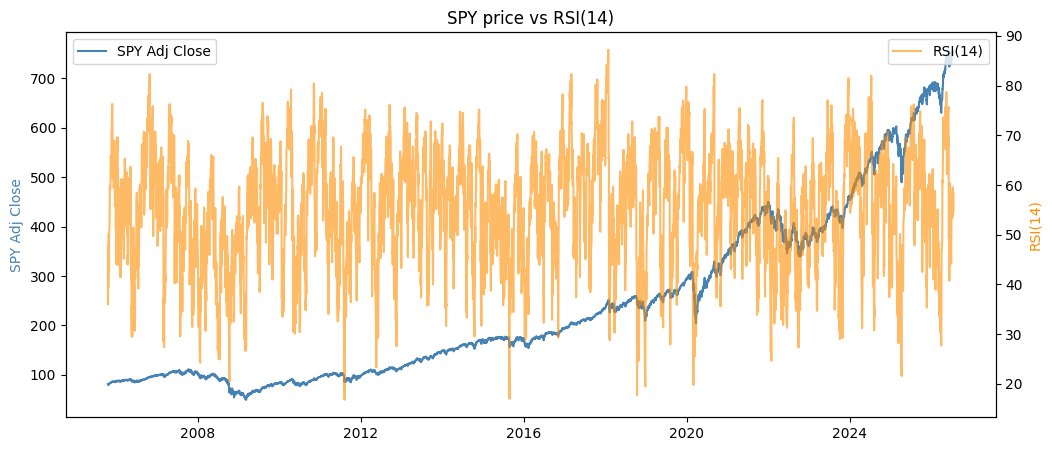

In [527]:
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
ax.plot(df_feat.index, df_feat["Adj Close"], color="steelblue", label="SPY Adj Close")
ax2.plot(df_feat.index, df_feat["rsi_14"], color="darkorange", alpha=0.6, label="RSI(14)")
ax.set_ylabel("SPY Adj Close", color="steelblue")
ax2.set_ylabel("RSI(14)", color="darkorange")
ax.set_title("SPY price vs RSI(14)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


### 2.9 Persist engineered dataset

In [528]:
out_path = os.path.join(DATA_DIR, "spy_features.csv")
df_feat.to_csv(out_path)

meta = {"feature_cols": feature_cols,
        "target_cols": ["target_ret_1d_fwd", "target_dir_1d_fwd"]}
import json
with open(os.path.join(DATA_DIR, "feature_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved {len(df_feat)} rows x {df_feat.shape[1]} cols -> {out_path}")


Saved 5218 rows x 51 cols -> data/spy_features.csv


# 3. HMM Regime Detection: SPY

Fits a Gaussian Hidden Markov Model on return/volatility features to identify latent
market regimes (e.g. "low-vol bull", "high-vol bear", "choppy/sideways"), then labels each day in the
dataset with its most likely regime. These regime labels are later fed into the CNN-LSTM-Attention model
as an additional input feature, and used as a filter in the backtest.


In [529]:
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_features.csv"), index_col="Date", parse_dates=True)

with open(os.path.join(DATA_DIR, "feature_meta.json")) as f:
    meta = json.load(f)

df.tail()

,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close,log_ret_1d,ret_5d,...,obv,obv_chg_10d,day_of_week,month,dow_sin,dow_cos,month_sin,month_cos,target_ret_1d_fwd,target_dir_1d_fwd
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-10,754.950012,754.950012,755.419983,748.099976,752.049988,42191300,15.03,4.569,0.004301,0.013655,...,17675140800,-0.000854,4,7,-0.951057,0.309017,-0.5,-0.866025,-0.007686,0
2026-07-13,749.169983,749.169983,753.909973,748.000000,752.469971,44013600,17.16,4.609,-0.007686,-0.002809,...,17631127200,0.000676,0,7,0.000000,1.000000,-0.5,-0.866025,0.003544,1
2026-07-14,751.830017,751.830017,753.340027,748.659973,750.909973,35143100,16.50,4.585,0.003544,0.005510,...,17666270300,-0.000621,1,7,0.951057,0.309017,-0.5,-0.866025,0.003956,1
2026-07-15,754.809998,754.809998,755.580017,750.200012,754.239990,43844800,15.67,4.545,0.003956,0.012624,...,17710115100,-0.001283,2,7,0.587785,-0.809017,-0.5,-0.866025,-0.005433,0
2026-07-16,750.719971,750.719971,754.570007,747.880005,752.760010,46409800,16.73,4.569,-0.005433,-0.001317,...,17663705300,-0.001248,3,7,-0.587785,-0.809017,-0.5,-0.866025,-0.009946,0


### 3.1 Choose HMM input features

HMMs are sensitive to high-dimensional, collinear inputs.
Return and volatility features are the classic choice for regime detection.


In [530]:
hmm_features = ["log_ret_1d", "realized_vol_21d", "vix_level"]
X_raw = df[hmm_features].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X.shape


(5218, 3)

### 3.2 Fit Gaussian HMM

We use 3 hidden states as a starting point: intuitively bull / bear / sideways-choppy.

In [531]:
N_STATES = 3
SEED = 42

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=1000,
    random_state=SEED,
    tol=1e-4,
)
model.fit(X)

print("Converged:", model.monitor_.converged)
print("Log-likelihood:", model.score(X))


Converged: True
Log-likelihood: -9675.208726538289


### 3.3 Decode hidden states and order-label them by mean return

In [532]:
hidden_states = model.predict(X)
df["hmm_state_raw"] = hidden_states

# Raw state indices from hmmlearn are arbitrary — relabel by mean 1d return so labels are consistent
# and interpretable: 0 = bear, 1 = sideways, 2 = bull (ascending mean return)
state_stats = df.groupby("hmm_state_raw")["log_ret_1d"].agg(["mean", "std", "count"])
state_stats = state_stats.sort_values("mean")
print(state_stats)

order = state_stats.index.tolist()  # ascending mean return
relabel_map = {raw_state: new_label for new_label, raw_state in enumerate(order)}
label_names = {0: "Bear", 1: "Sideways", 2: "Bull"} if N_STATES == 3 else \
              {i: f"Regime_{i}" for i in range(N_STATES)}

df["hmm_state"] = df["hmm_state_raw"].map(relabel_map)
df["hmm_regime"] = df["hmm_state"].map(label_names)

df[["log_ret_1d", "realized_vol_21d", "vix_level", "hmm_state", "hmm_regime"]].tail(10)


                   mean       std  count
hmm_state_raw                           
1             -0.001061  0.026090    647
0              0.000418  0.010809   2042
2              0.000814  0.005753   2529


,log_ret_1d,realized_vol_21d,vix_level,hmm_state,hmm_regime
Date,,,,,
2026-07-02,-0.001315,0.178506,16.150000,1,Sideways
2026-07-06,0.008690,0.179903,15.570000,1,Sideways
2026-07-07,-0.004763,0.180040,16.129999,1,Sideways
2026-07-08,-0.003094,0.154514,16.900000,1,Sideways
2026-07-09,0.008430,0.156797,15.840000,1,Sideways
2026-07-10,0.004301,0.156557,15.030000,1,Sideways
2026-07-13,-0.007686,0.147548,17.160000,1,Sideways
2026-07-14,0.003544,0.137109,16.500000,1,Sideways
2026-07-15,0.003956,0.136621,15.670000,1,Sideways


### 3.4 Regime statistics

In [533]:
regime_summary = df.groupby("hmm_regime")["log_ret_1d"].agg(
    mean_daily_ret="mean",
    ann_ret=lambda x: x.mean() * 252,
    ann_vol=lambda x: x.std() * np.sqrt(252),
    n_days="count",
)
regime_summary["sharpe"] = regime_summary["ann_ret"] / regime_summary["ann_vol"]
regime_summary


,mean_daily_ret,ann_ret,ann_vol,n_days,sharpe
hmm_regime,,,,,
Bear,-0.001061,-0.267423,0.414173,647,-0.645681
Bull,0.000814,0.205235,0.091333,2529,2.247113
Sideways,0.000418,0.105243,0.171580,2042,0.613372


### 3.5 Regime persistence: transition matrix

In [534]:
trans_df = pd.DataFrame(
    model.transmat_[np.ix_([order.index(s) for s in range(N_STATES)]*0 + order, order)]
    if False else model.transmat_,  # kept simple; see note below
)


# Simpler, robust approach: rebuild transition matrix directly in *relabeled* state space
n = N_STATES
trans_relabeled = np.zeros((n, n))
raw_seq = df["hmm_state_raw"].values
lab_seq = df["hmm_state"].values

for t in range(len(lab_seq) - 1):
    trans_relabeled[lab_seq[t], lab_seq[t+1]] += 1
trans_relabeled = trans_relabeled / trans_relabeled.sum(axis=1, keepdims=True)

trans_df = pd.DataFrame(trans_relabeled,
                         index=[label_names[i] for i in range(n)],
                         columns=[label_names[i] for i in range(n)])
print("Transition probabilities (row -> col):")
trans_df.round(3)


Transition probabilities (row -> col):


,Bear,Sideways,Bull
Bear,0.974,0.026,0.000
Sideways,0.008,0.974,0.019
Bull,0.000,0.015,0.985


### 3.6 Visualize regimes over the price series

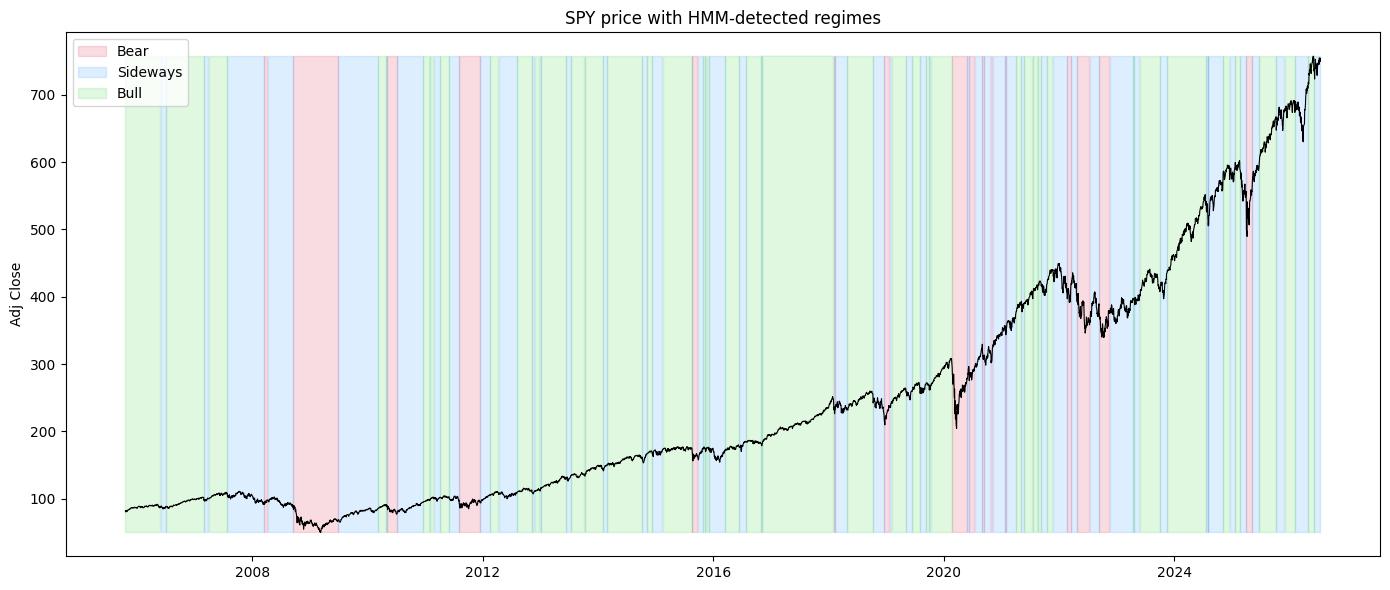

In [535]:
colors = {"Bear": "crimson", "Sideways": "dodgerblue", "Bull": "limegreen"}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["Adj Close"], color="black", linewidth=0.8, zorder=3)

for regime, color in colors.items():
    mask = df["hmm_regime"] == regime
    ax.fill_between(df.index, df["Adj Close"].min(), df["Adj Close"].max(),
                     where=mask, color=color, alpha=0.15, label=regime, step="mid")

ax.set_title("SPY price with HMM-detected regimes")
ax.set_ylabel("Adj Close")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 3.7 Model selection sanity check: score across different state counts (BIC-style)

In [536]:
results = []
for k in [2, 3, 4, 5]:
    m = GaussianHMM(n_components=k, covariance_type="full", n_iter=1000, random_state=SEED)
    m.fit(X)
    ll = m.score(X)
    n_params = (k-1) + k * (k - 1) + k * X.shape[1] + k * X.shape[1] * (X.shape[1] + 1) / 2
    bic = -2 * ll + n_params * np.log(len(X))
    results.append({"n_states": k, "log_likelihood": ll, "BIC": bic})

pd.DataFrame(results)


,n_states,log_likelihood,BIC
0,2,-12098.599976,24376.957211
1,3,-9675.215625,19650.026681
2,4,-7810.073559,16056.700460
3,5,-7201.647462,14993.925917


### 3.8 Persist regime-labeled dataset and model artifacts

In [537]:
out_path = os.path.join(DATA_DIR, "spy_features_regimes.csv")
df.to_csv(out_path)

import pickle
with open(os.path.join(DATA_DIR, "hmm_model.pkl"), "wb") as f:
    pickle.dump({"model": model, "scaler": scaler, "hmm_features": hmm_features,
                 "relabel_map": relabel_map, "label_names": label_names}, f)

print(f"Saved {len(df)} rows -> {out_path}")
print("Saved HMM model -> data/hmm_model.pkl")


Saved 5218 rows -> data/spy_features_regimes.csv
Saved HMM model -> data/hmm_model.pkl


# 4. CNN-LSTM-Attention Model: SPY Next-Day Direction / Return

Builds a hybrid deep learning model:

`1D-CNN (local pattern extraction)` → `LSTM (temporal dependencies)` → `Additive Attention (focus on
informative timesteps)` → `Dense head (prediction)`

Inputs are sliding windows of engineered features (including the HMM regime label as a one-hot feature).
The model is trained to predict **next-day direction** (classification) with an auxiliary **next-day
return** regression head.


In [538]:

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_features_regimes.csv"), index_col="Date", parse_dates=True)

with open(os.path.join(DATA_DIR, "feature_meta.json")) as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
print(f"{len(feature_cols)} base features + hmm_state one-hot")
df.tail()


Using device: cpu
41 base features + hmm_state one-hot


,Adj Close,Close,High,Low,Open,Volume,VIX_Close,TNX_Close,log_ret_1d,ret_5d,...,month,dow_sin,dow_cos,month_sin,month_cos,target_ret_1d_fwd,target_dir_1d_fwd,hmm_state_raw,hmm_state,hmm_regime
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-10,754.950012,754.950012,755.419983,748.099976,752.049988,42191300,15.03,4.569,0.004301,0.013655,...,7,-0.951057,0.309017,-0.5,-0.866025,-0.007686,0,0,1,Sideways
2026-07-13,749.169983,749.169983,753.909973,748.000000,752.469971,44013600,17.16,4.609,-0.007686,-0.002809,...,7,0.000000,1.000000,-0.5,-0.866025,0.003544,1,0,1,Sideways
2026-07-14,751.830017,751.830017,753.340027,748.659973,750.909973,35143100,16.50,4.585,0.003544,0.005510,...,7,0.951057,0.309017,-0.5,-0.866025,0.003956,1,0,1,Sideways
2026-07-15,754.809998,754.809998,755.580017,750.200012,754.239990,43844800,15.67,4.545,0.003956,0.012624,...,7,0.587785,-0.809017,-0.5,-0.866025,-0.005433,0,0,1,Sideways
2026-07-16,750.719971,750.719971,754.570007,747.880005,752.760010,46409800,16.73,4.569,-0.005433,-0.001317,...,7,-0.587785,-0.809017,-0.5,-0.866025,-0.009946,0,0,1,Sideways


### 4.1 Add regime one-hot encoding to the feature set

In [539]:
regime_dummies = pd.get_dummies(df["hmm_state"], prefix="regime").astype(float)
df = pd.concat([df, regime_dummies], axis=1)

model_feature_cols = feature_cols + list(regime_dummies.columns)
print(f"Total model input features: {len(model_feature_cols)}")


Total model input features: 44


### 4.2 Chronological train / validation / test split

No shuffling across the split boundary, and the scaler is fit on train only
to avoid lookahead bias.


In [540]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {train_df.index.min().date()} -> {train_df.index.max().date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index.min().date()} -> {val_df.index.max().date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index.min().date()} -> {test_df.index.max().date()} ({len(test_df)} rows)")


Train: 2005-10-17 -> 2020-04-21 (3652 rows)
Val:   2020-04-22 -> 2023-05-31 (783 rows)
Test:  2023-06-01 -> 2026-07-16 (783 rows)


In [541]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_df[model_feature_cols])

def scale(d):
    out = d.copy()
    out[model_feature_cols] = scaler.transform(d[model_feature_cols])
    return out

train_s, val_s, test_s = scale(train_df), scale(val_df), scale(test_df)


### 4.3 Build sliding-window sequences

In [542]:
SEQ_LEN = 60  # lookback window (trading days)

def make_sequences(d, feature_cols, seq_len):
    X_feat = d[feature_cols].values.astype(np.float32)
    y_dir = d["target_dir_1d_fwd"].values.astype(np.float32)
    y_ret = d["target_ret_1d_fwd"].values.astype(np.float32)
    dates = d.index

    X_seq, y_dir_seq, y_ret_seq, date_seq = [], [], [], []
    for i in range(seq_len, len(d)):
        X_seq.append(X_feat[i - seq_len:i])
        y_dir_seq.append(y_dir[i])
        y_ret_seq.append(y_ret[i])
        date_seq.append(dates[i])

    return (np.array(X_seq), np.array(y_dir_seq), np.array(y_ret_seq), np.array(date_seq))

X_train, ydir_train, yret_train, dates_train = make_sequences(train_s, model_feature_cols, SEQ_LEN)
X_val, ydir_val, yret_val, dates_val = make_sequences(val_s, model_feature_cols, SEQ_LEN)
X_test, ydir_test, yret_test, dates_test = make_sequences(test_s, model_feature_cols, SEQ_LEN)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (3592, 60, 44)  Val: (723, 60, 44)  Test: (723, 60, 44)


In [543]:
class SeqDataset(Dataset):
    def __init__(self, X, y_dir, y_ret):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_dir = torch.tensor(y_dir, dtype=torch.float32)
        self.y_ret = torch.tensor(y_ret, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_dir[idx], self.y_ret[idx]

BATCH_SIZE = 64
train_loader = DataLoader(SeqDataset(X_train, ydir_train, yret_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SeqDataset(X_val, ydir_val, yret_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SeqDataset(X_test, ydir_test, yret_test), batch_size=BATCH_SIZE, shuffle=False)


### 4.4 Model: CNN → LSTM → Additive Attention → Dual head

In [544]:
class AdditiveAttention(nn.Module):
    """Bahdanau-style additive attention over LSTM outputs."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden_dim)
        scores = self.v(torch.tanh(self.attn(lstm_out)))          # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)                    # (batch, seq_len, 1)
        context = torch.sum(weights * lstm_out, dim=1)            # (batch, hidden_dim)
        return context, weights.squeeze(-1)                       # context, attention weights


class CNNLSTMAttention(nn.Module):
    def __init__(self, n_features, cnn_channels=64, lstm_hidden=64, lstm_layers=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.conv2 = nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.attention = AdditiveAttention(lstm_hidden)

        self.head_dir = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
        self.head_ret = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features) -> Conv1d expects (batch, channels, seq_len)
        x = x.transpose(1, 2)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = x.transpose(1, 2)  # back to (batch, seq_len, channels)

        lstm_out, _ = self.lstm(x)             # (batch, seq_len, lstm_hidden)
        context, attn_weights = self.attention(lstm_out)

        dir_logit = self.head_dir(context).squeeze(-1)   # (batch,)
        ret_pred = self.head_ret(context).squeeze(-1)    # (batch,)
        return dir_logit, ret_pred, attn_weights


n_features = X_train.shape[2]
model = CNNLSTMAttention(n_features=n_features).to(device)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


CNNLSTMAttention(
  (conv1): Conv1d(44, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3)
  (attention): AdditiveAttention(
    (attn): Linear(in_features=64, out_features=64, bias=True)
    (v): Linear(in_features=64, out_features=1, bias=False)
  )
  (head_dir): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
  (head_ret): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=

### 4.5 Training loop

Joint loss: BCE (direction) + MSE (return), with early stopping on validation direction accuracy.

In [545]:
LR = 1e-3
EPOCHS = 60
PATIENCE = 8
RET_LOSS_WEIGHT = 0.5

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
bce_loss_fn = nn.BCEWithLogitsLoss()
mse_loss_fn = nn.MSELoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n_obs = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for Xb, ydb, yrb in loader:
            Xb, ydb, yrb = Xb.to(device), ydb.to(device), yrb.to(device)
            if train:
                optimizer.zero_grad()
            dir_logit, ret_pred, _ = model(Xb)
            loss = bce_loss_fn(dir_logit, ydb) + RET_LOSS_WEIGHT * mse_loss_fn(ret_pred, yrb)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * len(Xb)
            correct += ((torch.sigmoid(dir_logit) > 0.5).float() == ydb).sum().item()
            n_obs += len(Xb)
    return total_loss / n_obs, correct / n_obs

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state, patience_ctr = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_acc)

    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc); history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc, best_state, patience_ctr = val_acc, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        patience_ctr += 1

    print(f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val_loss {val_loss:.4f} acc {val_acc:.3f}")

    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (best val_acc={best_val_acc:.3f})")
        break

model.load_state_dict(best_state)


Epoch 01 | train_loss 0.6902 acc 0.550 | val_loss 0.6927 acc 0.524
Epoch 02 | train_loss 0.6886 acc 0.550 | val_loss 0.6934 acc 0.524
Epoch 03 | train_loss 0.6885 acc 0.551 | val_loss 0.6935 acc 0.524
Epoch 04 | train_loss 0.6885 acc 0.550 | val_loss 0.6946 acc 0.524
Epoch 05 | train_loss 0.6884 acc 0.550 | val_loss 0.6949 acc 0.524
Epoch 06 | train_loss 0.6881 acc 0.550 | val_loss 0.6975 acc 0.524
Epoch 07 | train_loss 0.6867 acc 0.550 | val_loss 0.6984 acc 0.524
Epoch 08 | train_loss 0.6872 acc 0.550 | val_loss 0.7007 acc 0.524
Epoch 09 | train_loss 0.6858 acc 0.550 | val_loss 0.7013 acc 0.524
Early stopping at epoch 9 (best val_acc=0.524)


<All keys matched successfully>

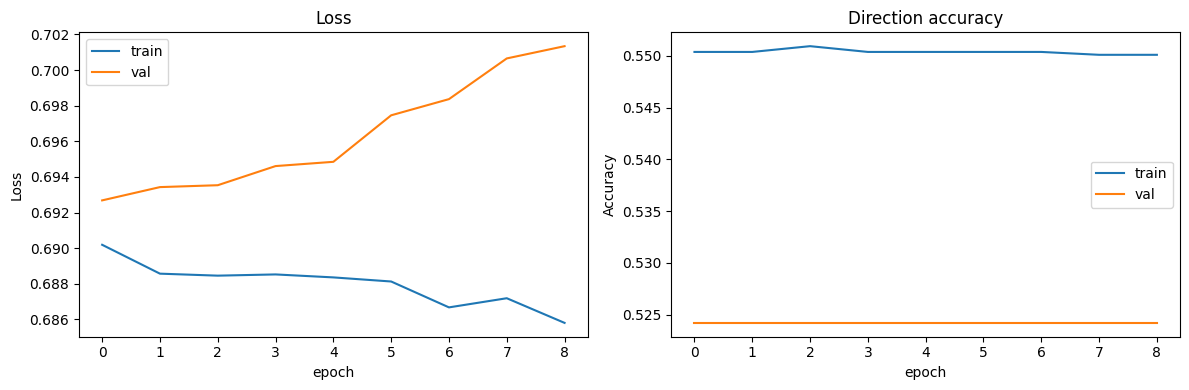

In [546]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Direction accuracy"); axes[1].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout(); plt.show()


### 4.6 Evaluate on held-out test set

In [547]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error

model.eval()
all_probs, all_dir_true, all_ret_pred, all_ret_true, all_attn = [], [], [], [], []

with torch.no_grad():
    for Xb, ydb, yrb in test_loader:
        Xb = Xb.to(device)
        dir_logit, ret_pred, attn_w = model(Xb)
        all_probs.append(torch.sigmoid(dir_logit).cpu().numpy())
        all_dir_true.append(ydb.numpy())
        all_ret_pred.append(ret_pred.cpu().numpy())
        all_ret_true.append(yrb.numpy())
        all_attn.append(attn_w.cpu().numpy())

probs = np.concatenate(all_probs)
dir_true = np.concatenate(all_dir_true)
ret_pred = np.concatenate(all_ret_pred)
ret_true = np.concatenate(all_ret_true)
attn = np.concatenate(all_attn)
preds = (probs > 0.5).astype(int)

print("Direction classification:")
print(f"  Accuracy : {accuracy_score(dir_true, preds):.3f}")
print(f"  Precision: {precision_score(dir_true, preds):.3f}")
print(f"  Recall   : {recall_score(dir_true, preds):.3f}")
print(f"  F1       : {f1_score(dir_true, preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(dir_true, probs):.3f}")
print(f"\nReturn regression:")
print(f"  RMSE     : {np.sqrt(mean_squared_error(ret_true, ret_pred)):.5f}")
print(f"  Baseline (predict 0): {np.sqrt(mean_squared_error(ret_true, np.zeros_like(ret_true))):.5f}")


Direction classification:
  Accuracy : 0.571
  Precision: 0.571
  Recall   : 1.000
  F1       : 0.727
  ROC-AUC  : 0.535

Return regression:
  RMSE     : 0.00984
  Baseline (predict 0): 0.00972


### 4.7 Inspect attention weights (interpretability)

Average attention profile across the test set — which lagged days does the model lean on most?

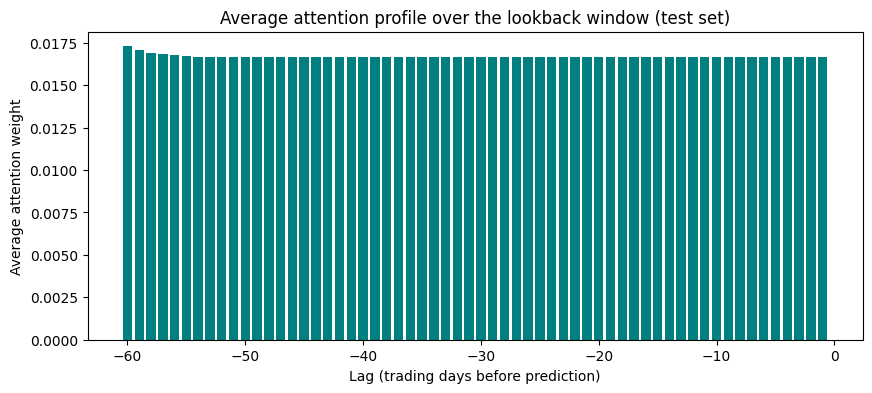

In [548]:
avg_attn = attn.mean(axis=0)  # (seq_len,)
plt.figure(figsize=(10, 4))
plt.bar(range(-SEQ_LEN, 0), avg_attn, color="teal")
plt.xlabel("Lag (trading days before prediction)")
plt.ylabel("Average attention weight")
plt.title("Average attention profile over the lookback window (test set)")
plt.show()


### 4.8 Save predictions and model

In [549]:
pred_df = pd.DataFrame({
    "date": dates_test,
    "prob_up": probs,
    "pred_dir": preds,
    "true_dir": dir_true.astype(int),
    "pred_ret": ret_pred,
    "true_ret": ret_true,
}).set_index("date")

pred_df.to_csv(os.path.join(DATA_DIR, "test_predictions.csv"))

torch.save({
    "model_state": model.state_dict(),
    "model_feature_cols": model_feature_cols,
    "seq_len": SEQ_LEN,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
}, os.path.join(DATA_DIR, "cnn_lstm_attention_model.pt"))

print(f"Saved {len(pred_df)} test predictions -> data/test_predictions.csv")
print("Saved model -> data/cnn_lstm_attention_model.pt")


Saved 723 test predictions -> data/test_predictions.csv
Saved model -> data/cnn_lstm_attention_model.pt
